# Functions

## Signal
* Height above ground (relative and absolute)
* Vertical structure (e.g. is structure angled?)
* Canopy separation (leaves)
* Local roughness - clarify what this is
* Distinguish shrub vs tree characteristics


In [1]:
1

1

In [2]:
from pathlib import Path
import laspy
import numpy as np

fname = "lid_1.laz"
sample_dir = Path("sample_data")
out_dir = Path("processed")

c:\Users\seani\miniforge3\envs\fe_als_alt\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [ ]:
import numpy as np
from scipy.spatial import cKDTree
import time

def calculate_roughness_knn(points, k=20):
    """
    Calculates local roughness (Z-standard deviation) using K-Nearest Neighbors.
    
    Parameters:
        points (numpy.ndarray): Nx3 array of X, Y, Z coordinates.
        k (int): Number of nearest neighbors to evaluate.
        
    Returns:
        numpy.ndarray: 1D array of roughness values matching the input point order.
    """
    # 1. Isolate X and Y for a 2.5D surface search 
    # (Use points[:, :3] if you want a true 3D spherical neighborhood)
    xy = points[:, :2]
    z = points[:, 2]
    
    # 2. Build the spatial index
    print("Building KDTree...")
    tree = cKDTree(xy)
    
    # 3. Query the 'k' closest neighbors for every single point
    # workers=-1 tells SciPy to parallelize across all available CPU cores
    print(f"Querying {k} nearest neighbors...")
    distances, indices = tree.query(xy, k=k, workers=-1)
    
    # 4. Extract the Z-elevations for all retrieved neighbors
    # 'indices' is an (N, k) array. This maps our Z array to an (N, k) array of elevations.
    neighbor_z_values = z[indices]
    
    # 5. Vectorized Standard Deviation
    # Calculate the standard deviation across the k-axis (axis=1)
    print("Calculating standard deviation...")
    roughness = np.std(neighbor_z_values, axis=1)
    
    return roughness



In [4]:
def process_las_roughness(input_path, output_path, k=30):
    las = laspy.read(input_path)
    points = np.vstack((las.x, las.y, las.z)).transpose()
    
    roughness = calculate_roughness_knn(points, k=k)
    
    las.add_extra_dim(laspy.ExtraBytesParams(name="roughness", type=np.float32))
    las.roughness = roughness
    
    las.write(output_path)
    print(f"Saved processed point cloud to {output_path}")

process_las_roughness(sample_dir/fname, out_dir/fname)

Building KDTree...
Querying 30 nearest neighbors...
Calculating standard deviation...
Saved processed point cloud to processed\lid_1.laz


In [5]:
import plotly.graph_objects as go
import numpy as np

def plot_als(input_path):
    las = laspy.read(input_path)

    subset_size = 50000 
    random_indices = np.random.choice(len(las.x), size=subset_size, replace=False)

    x_als, y_als, z_als = las.x, las.y, las.z
    # 2. We create an interactive 3D scatter plot
    fig = go.Figure(data=[go.Scatter3d(
        x=x_als[random_indices],
        y=y_als[random_indices],
        z=z_als[random_indices],
        mode='markers',
        marker=dict(
            size=2,                     
            color=z_als[:subset_size],   # Color points by height (just to make it look nicer :D)
            colorscale='Viridis',        
            opacity=0.8                  
        )
    )])

    # 3. We add a few details and show the figure
    fig.update_layout(
        title="Airborne Laser Scanning (ALS) Point Cloud",
        scene=dict(
            xaxis_title="X (m)",
            yaxis_title="Y (m)",
            zaxis_title="Z (m)"
        ),
        margin=dict(l=0, r=0, b=0, t=40)  
    )

    fig.show()

plot_als(sample_dir / fname)

In [6]:
import pdal
import json

def calculate_height_above_ground(input_las, output_las):
    """
    Runs a PDAL pipeline to classify ground points and calculate 
    Height Above Ground (HAG) for a LAS/LAZ file.
    """
    
    # Define the PDAL pipeline as a Python dictionary - C++ compilation
    pipeline_dict = [
        {
            "type": "readers.las",
            "filename": input_las
        },
        {
            # Step 1: Ground Classification
            # SMRF (Simple Morphological Filter) is generally faster and 
            # requires less parameter tuning than CSF for standard terrain.
            "type": "filters.smrf",
            "ignore": "Classification[7:7]", # Ignore noise points if they exist
            "slope": 0.15,
            "window": 18,
            "threshold": 0.5,
            "scalar": 1.25
        },
        {
            # Step 2: Calculate Height Above Ground
            # hag_nn uses nearest-neighbor interpolation from the ground surface.
            "type": "filters.hag_nn"
        },
        {
            # Step 3: Write the output
            "type": "writers.las",
            "filename": output_las,
            # We must explicitly tell the writer to include our new HAG dimension
            "extra_dims": "HeightAboveGround=float32" 
        }
    ]
    
    # Convert the dictionary to a JSON string
    pipeline_json = json.dumps(pipeline_dict)
    
    # Create and execute the PDAL pipeline
    print(f"Starting PDAL pipeline for {input_las}...")
    pipeline = pdal.Pipeline(pipeline_json)
    
    try:
        # execute() returns the number of points processed
        count = pipeline.execute()
        print(f"Successfully processed {count} points.")
        print(f"Saved to {output_las} with new 'HeightAboveGround' dimension.")
        
    except Exception as e:
        print(f"Pipeline failed: {e}")


calculate_height_above_ground(str(sample_dir/fname), str(out_dir/fname))

Starting PDAL pipeline for sample_data\lid_1.laz...
Successfully processed 1514242 points.
Saved to processed\lid_1.laz with new 'HeightAboveGround' dimension.


In [7]:
import numpy as np
import open3d as o3d
import laspy

def calculate_surface_angle(input_las, output_las, knn=30):
    """
    Calculates surface normals and derived slope angle for a point cloud.
    
    Parameters:
        input_las (str): Path to input LAS/LAZ file.
        output_las (str): Path to save the processed LAS/LAZ file.
        knn (int): Number of nearest neighbors to use for normal estimation.
    """
    print(f"Reading {input_las}...")
    las = laspy.read(input_las)
    
    # 1. Stack coordinates into an Nx3 NumPy array
    points = np.vstack((las.x, las.y, las.z)).transpose()
    
    # 2. Convert NumPy array to Open3D PointCloud object
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    
    # 3. Estimate Normals
    # We use a KDTree search with a defined number of neighbors (knn)
    print(f"Estimating normals using {knn} nearest neighbors...")
    pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamKNN(knn=knn)
    )
    
    # Optional but recommended: Align normals to point generally "up"
    # This helps keep the vectors consistent
    pcd.orient_normals_to_align_with_direction([0., 0., 1.])
    
    # 4. Extract the normals back into a NumPy array
    normals = np.asarray(pcd.normals)
    
    # 5. Calculate the Slope Angle (in degrees)
    print("Calculating surface angles...")
    # Extract the Z component of the normal vectors
    nz = normals[:, 2]
    
    # Calculate arccosine of the absolute Z value (returns radians)
    slope_radians = np.arccos(np.abs(nz))
    
    # Convert radians to degrees for easier interpretation (0 = flat, 90 = vertical)
    slope_degrees = np.degrees(slope_radians)
    
    # 6. Save back to LAS
    print("Writing results to new LAS file...")
    
    # Add new dimensions for the normal vectors (useful for advanced processing)
    # and the calculated slope angle
    las.add_extra_dim(laspy.ExtraBytesParams(name="normal_x", type=np.float32))
    las.add_extra_dim(laspy.ExtraBytesParams(name="normal_y", type=np.float32))
    las.add_extra_dim(laspy.ExtraBytesParams(name="normal_z", type=np.float32))
    las.add_extra_dim(laspy.ExtraBytesParams(name="slope_degrees", type=np.float32))
    
    las.normal_x = normals[:, 0]
    las.normal_y = normals[:, 1]
    las.normal_z = normals[:, 2]
    las.slope_degrees = slope_degrees
    
    las.write(output_las)
    print(f"Success! Saved to {output_las}.")

calculate_surface_angle(out_dir/fname, out_dir/fname)

Reading processed\lid_1.laz...
Estimating normals using 30 nearest neighbors...
Calculating surface angles...
Writing results to new LAS file...
Success! Saved to processed\lid_1.laz.


In [8]:
import numpy as np
import open3d as o3d
import laspy

def segment_trees_dbscan(input_las, output_las, eps=0.8, min_points=15, height_threshold=2.0):
    """
    Segments individual tree canopies using 3D DBSCAN clustering.
    
    Parameters:
        input_las (str): Path to input LAS/LAZ (must have HeightAboveGround).
        output_las (str): Path to save the clustered LAS/LAZ.
        eps (float): Maximum distance between two points to be considered neighbors.
        min_points (int): Minimum number of points to form a dense cluster.
        height_threshold (float): Minimum height above ground to be considered canopy.
    """
    print(f"Reading {input_las}...")
    las = laspy.read(input_las)
    
    # 1. Filter the points
    # We only want to cluster points that are high enough to be trees/tall shrubs.
    # We assume you have the 'HeightAboveGround' dimension from the PDAL step.
    # If not, you can swap this to use the raw Z value, but HAG is much better.
    try:
        hag = las.HeightAboveGround
    except AttributeError:
        print("Error: 'HeightAboveGround' dimension not found. Please run PDAL HAG first.")
        return

    # Create a boolean mask: True for points > height_threshold
    canopy_mask = hag > height_threshold
    
    # Extract only the XYZ coordinates of the canopy points
    canopy_points = np.vstack((las.x[canopy_mask], 
                               las.y[canopy_mask], 
                               las.z[canopy_mask])).transpose()
    
    # 2. Convert to Open3D PointCloud
    print(f"Clustering {len(canopy_points)} canopy points...")
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(canopy_points)
    
    # 3. Run DBSCAN
    # This returns an array of cluster labels. 
    # Label -1 means "noise" (points that didn't fit into any dense cluster).
    # Labels 0, 1, 2... are unique tree IDs.
    labels = np.array(pcd.cluster_dbscan(eps=eps, min_points=min_points, print_progress=True))
    
    max_label = labels.max()
    print(f"Identified {max_label + 1} distinct clusters (trees/canopy sections).")
    
    # 4. Map the labels back to the original LAS file
    # Initialize an array of -1 (noise/unclassified) for ALL points
    full_labels = np.full(len(las.points), -1, dtype=np.int32)
    
    # Inject the canopy labels into the correct indices using our mask
    full_labels[canopy_mask] = labels
    
    # 5. Save back to LAS
    print("Writing results to new LAS file...")
    las.add_extra_dim(laspy.ExtraBytesParams(name="tree_id", type=np.int32))
    las.tree_id = full_labels
    
    las.write(output_las)
    print(f"Success! Saved to {output_las}.")

segment_trees_dbscan(out_dir/fname, out_dir/fname)

Reading processed\lid_1.laz...
Clustering 730453 canopy points...
Identified 4779 distinct clusters (trees/canopy sections).
Writing results to new LAS file...
Success! Saved to processed\lid_1.laz.


In [9]:
import numpy as np
import laspy

def classify_vegetation_rules(input_las, output_las):
    """
    Classifies points into Shrubs vs Trees using hardcoded logic rules.
    """
    print(f"Reading {input_las}...")
    las = laspy.read(input_las)
    
    # Ensure HAG exists
    try:
        hag = las.HeightAboveGround
    except AttributeError:
        print("Error: 'HeightAboveGround' not found. Run PDAL HAG first.")
        return

    # 1. Initialize a new classification array (0 = Unclassified)
    # We will use standard LAS classification codes: 3 = Low Veg (Shrub), 5 = High Veg (Tree)
    veg_class = np.zeros(len(las.points), dtype=np.uint8)
    
    # 2. Define the Shrub Mask
    # Rule: Height between 0.5m and 3.0m.
    is_shrub = (hag >= 0.5) & (hag < 3.0)
    
    # 3. Define the Tree Mask
    # Rule: Height > 3.0m OR (Height > 1.5m AND it generated multiple returns)
    # The second condition catches shorter trees with complex, branching canopies.
    is_tree = (hag >= 3.0) | ((hag >= 1.5) & (las.number_of_returns > 1))
    
    # 4. Apply the masks
    # We apply trees second so that if a point meets both criteria, it defaults to tree
    veg_class[is_shrub] = 3
    veg_class[is_tree] = 5
    
    # 5. Save the results
    # We can either overwrite the native LAS 'classification' dimension or create a new one
    las.classification = veg_class
    
    print("Writing results...")
    las.write(output_las)
    print(f"Success! Classification saved to {output_las}.")

classify_vegetation_rules(out_dir/fname, out_dir/fname)

Reading processed\lid_1.laz...
Writing results...
Success! Classification saved to processed\lid_1.laz.


In [10]:
import numpy as np
from scipy.spatial import cKDTree

def get_overlap_mask(points, bbox_overlap):
    """
    Returns a boolean mask of points that fall strictly within the overlap bounding box.
    bbox_overlap format: [min_x, max_x, min_y, max_y]
    """
    min_x, max_x, min_y, max_y = bbox_overlap
    x = points[:, 0]
    y = points[:, 1]
    
    mask = (x >= min_x) & (x <= max_x) & (y >= min_y) & (y <= max_y)
    return mask

def align_tile_labels(points_A, labels_A, points_B, labels_B, bbox_overlap):
    """
    Aligns the K-Means labels of Tile B to match the semantic meaning of Tile A 
    using the shared spatial overlap.
    
    Returns:
        numpy.ndarray: The remapped labels for Tile B.
    """
    print("Isolating overlap regions...")
    # 1. Isolate the points that live in the shared boundary
    mask_A = get_overlap_mask(points_A, bbox_overlap)
    mask_B = get_overlap_mask(points_B, bbox_overlap)
    
    overlap_points_A = points_A[mask_A]
    overlap_labels_A = labels_A[mask_A]
    
    overlap_points_B = points_B[mask_B]
    overlap_labels_B = labels_B[mask_B]
    
    if len(overlap_points_A) == 0 or len(overlap_points_B) == 0:
        raise ValueError("No points found inside the provided overlap bounding box.")

    print(f"Found {len(overlap_points_A)} points in Tile A's overlap and {len(overlap_points_B)} in Tile B's.")

    # 2. Match points perfectly using a KD-Tree
    # We query Tile A's tree using Tile B's points to find the exact nearest neighbors
    print("Matching points across tiles...")
    tree_A = cKDTree(overlap_points_A[:, :2]) # Match based on X, Y
    distances, indices_A = tree_A.query(overlap_points_B[:, :2], k=1)
    
    # 3. Build a mapping dictionary based on majority vote
    # We map what Tile B *thinks* it is, to what Tile A *knows* it is
    print("Calculating label consensus...")
    unique_labels_B = np.unique(labels_B)
    label_mapping = {}
    
    for label_b in unique_labels_B:
        # Find all points in the overlap where Tile B predicted 'label_b'
        b_indices_for_this_label = np.where(overlap_labels_B == label_b)[0]
        
        # If this label doesn't exist in the overlap, we can't map it safely
        if len(b_indices_for_this_label) == 0:
            print(f"Warning: Label {label_b} not found in overlap. Leaving as is.")
            label_mapping[label_b] = label_b
            continue
            
        # Get the corresponding indices in Tile A's overlap
        matched_indices_in_A = indices_A[b_indices_for_this_label]
        
        # Get what Tile A labeled those exact same points
        corresponding_labels_in_A = overlap_labels_A[matched_indices_in_A]
        
        # Find the most common label in Tile A for this group (Majority Vote)
        # np.bincount tallies the occurrences, argmax gets the most frequent
        most_frequent_label_A = np.bincount(corresponding_labels_in_A).argmax()
        
        label_mapping[label_b] = most_frequent_label_A
        print(f"Tile B Label {label_b}  --->  Maps to Tile A Label {most_frequent_label_A}")

    # 4. Apply the mapping to the ENTIRETY of Tile B
    print("Applying remapped labels to Tile B...")
    remapped_labels_B = np.copy(labels_B)
    for old_label, new_label in label_mapping.items():
        remapped_labels_B[labels_B == old_label] = new_label
        
    return remapped_labels_B

# Rasterization

In [11]:
import numpy as np
import laspy
from scipy.stats import binned_statistic_2d
import rasterio
from rasterio.transform import from_origin
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import distance_transform_edt
from scipy.ndimage import minimum_filter

# note this expects a 2d image as the result of ALS compression above
def calculate_distance_to_tall_canopy(chm_grid, resolution=1.0, height_threshold=5.0):
    """
    Calculates the distance from every pixel to the nearest tall canopy pixel.
    
    Parameters:
        chm_grid (np.ndarray): The gap-filled Canopy Height Model raster.
        resolution (float): The pixel size in meters.
        height_threshold (float): Minimum height to be considered "tall canopy".
    """
    print(f"Calculating distance to canopy > {height_threshold}m...")
    
    # 1. Create a boolean mask of the tall canopy
    # True = Tall Canopy, False = Open space / Short veg
    is_tall = chm_grid >= height_threshold
    
    # 2. Prepare the grid for the EDT algorithm
    # EDT measures the distance to the closest '0' (False) value. 
    # Therefore, we need to invert our mask: Tall canopy becomes 0, everything else is 1.
    edt_input = ~is_tall
    
    # 3. Run the distance transform
    # This returns the distance in *pixels*
    distance_in_pixels = distance_transform_edt(edt_input)
    
    # 4. Convert to physical units (meters)
    distance_meters = distance_in_pixels * resolution
    
    return distance_meters.astype(np.float32)


def calculate_local_relief(chm_grid, window_size_pixels=5):
    """
    Calculates Local Relief using a moving focal window.
    
    Parameters:
        chm_grid (np.ndarray): The gap-filled Canopy Height Model raster.
        window_size_pixels (int): The size of the moving window (e.g., 5 means a 5x5 pixel box).
                                  Must be an odd number to have a true center pixel.
    """
    print(f"Calculating local relief (focal window: {window_size_pixels}x{window_size_pixels})...")
    
    # 1. Calculate the minimum height in the neighborhood of every pixel
    local_min_grid = minimum_filter(chm_grid, size=window_size_pixels)
    
    # 2. Subtract the local minimum from the actual height
    local_relief = chm_grid - local_min_grid
    
    # Ensure no negative artifacts from floating point math
    local_relief = np.maximum(local_relief, 0.0)

    return local_relief.astype(np.float32)

def create_height_rasters(input_las, output_prefix, resolution=1.0):
    """
    Generates core height rasters (Max, Mean, and Count) from a LAS file.
    """
    las = laspy.read(input_las)
    x, y, z = las.x, las.y, las.HeightAboveGround # Assuming HAG is calculated
    
    # 1. Define the grid boundaries based on the point cloud extent
    x_min, x_max = np.min(x), np.max(x)
    y_min, y_max = np.min(y), np.max(y)
    
    # Calculate number of pixels (bins)
    cols = int(np.ceil((x_max - x_min) / resolution))
    rows = int(np.ceil((y_max - y_min) / resolution))
    
    # Define bin edges
    x_edges = np.linspace(x_min, x_max, cols + 1)
    y_edges = np.linspace(y_min, y_max, rows + 1)
    
    print(f"Creating {cols}x{rows} rasters at {resolution}m resolution...")
    
    # 2. Calculate Statistics using SciPy
    # MAX (Canopy Height Model)
    chm_grid, _, _, _ = binned_statistic_2d(x, y, z, statistic='max', bins=[x_edges, y_edges])
    
    # MEAN
    mean_grid, _, _, _ = binned_statistic_2d(x, y, z, statistic='mean', bins=[x_edges, y_edges])
    
    # POINT COUNT (needed for density metrics later)
    count_grid, _, _, _ = binned_statistic_2d(x, y, z, statistic='count', bins=[x_edges, y_edges])

    # 3. Format grids for GIS (SciPy outputs X/Y differently than standard images)
    # We must transpose and flip the array so North is up
    chm_grid = np.rot90(chm_grid)
    mean_grid = np.rot90(mean_grid)
    

    safe_chm_math = np.nan_to_num(chm_grid, nan=0.0)
    dist_to_canopy = calculate_distance_to_tall_canopy(safe_chm_math, resolution=1.0, height_threshold=5.0)
    local_relief = calculate_local_relief(safe_chm_math, window_size_pixels=5)

    # Replace NaNs (pixels with no points) with a NoData value (e.g., -9999)
    chm_grid = np.nan_to_num(chm_grid, nan=-9999)
    mean_grid = np.nan_to_num(mean_grid, nan=-9999)
    dist_to_canopy = np.nan_to_num(dist_to_canopy, nan=-9999)
    local_relief = np.nan_to_num(local_relief, nan=-9999)
    
    # 4. Save to GeoTIFF using Rasterio
    transform = from_origin(x_min, y_max, resolution, resolution)
    
    def save_tiff(grid, filename):
        with rasterio.open(
            filename, 'w', driver='GTiff',
            height=grid.shape[0], width=grid.shape[1],
            count=1, dtype=grid.dtype,
            crs=las.header.parse_crs(), # Retain original projection
            transform=transform, nodata=-9999
        ) as dst:
            dst.write(grid, 1)
            
    save_tiff(chm_grid, f"{output_prefix}_CHM_Max.tif")
    save_tiff(mean_grid, f"{output_prefix}_Mean.tif")
    save_tiff(dist_to_canopy, f"{output_prefix}_Distance_to_Tall_Canopy.tif")
    save_tiff(local_relief, f"{output_prefix}_Local_Relief.tif")
    print("Rasters saved successfully.")

create_height_rasters(out_dir/fname, out_dir/fname)

Creating 731x221 rasters at 1.0m resolution...
Calculating distance to canopy > 5.0m...
Calculating local relief (focal window: 5x5)...
Rasters saved successfully.


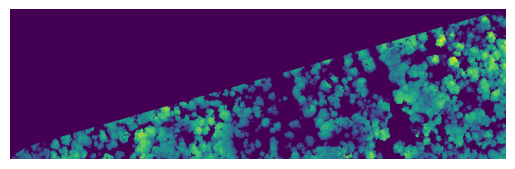

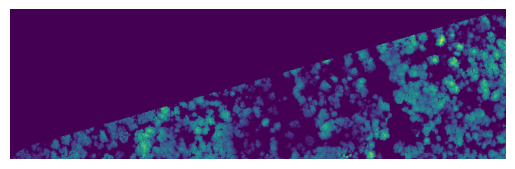

In [12]:
from fe_2d import get_all_bands
import matplotlib.pyplot as plt

with rasterio.open(f"{out_dir/fname}_CHM_Max.tif") as src:
    for band in get_all_bands(src):
        plt.imshow(band)
        plt.axis("off")
        plt.show()

with rasterio.open(f"{out_dir/fname}_Mean.tif") as src:
    for band in get_all_bands(src):
        plt.imshow(band)
        plt.axis("off")
        plt.show()

In [13]:
import numpy as np
from scipy.spatial import cKDTree
import laspy
import time

def calculate_knn_node_metrics(points, k=30):
    """
    Calculates variance, roughness, vertical heterogeneity, and local maxima density 
    for each node based on its K-Nearest Neighbors.
    """
    # 1. Build the KD-Tree
    print(f"Building KDTree and querying {k} nearest neighbors...")
    tree = cKDTree(points)
    distances, indices = tree.query(points, k=k, workers=-1)
    
    # 2. Extract Z-values for all neighbors
    z = points[:, 2]
    neighbor_z = z[indices]
    
    # --- Metrics ---
    print("Calculating local height variance...")
    variance = np.var(neighbor_z, axis=1)
    
    print("Calculating roughness...")
    roughness = np.std(neighbor_z, axis=1)
    
    print("Calculating vertical heterogeneity...")
    mean_z = np.mean(neighbor_z, axis=1)
    safe_mean_z = np.where(mean_z == 0, 1e-6, mean_z)
    heterogeneity = roughness / safe_mean_z
    
    print("Calculating local maxima density...")
    is_local_max = (z == np.max(neighbor_z, axis=1))
    neighbor_is_max = is_local_max[indices]
    maxima_count = np.sum(neighbor_is_max, axis=1)
    maxima_density = maxima_count / k
    
    return variance, roughness, heterogeneity, maxima_density


def process_las_knn_metrics(input_las, output_las, k=30):
    """
    Reads a LAS file, calculates KNN metrics for every point, 
    and saves the results to a new LAS file.
    """
    print(f"\nReading {input_las}...")
    las = laspy.read(input_las)
    
    # 1. Stack X, Y, Z coordinates into an Nx3 NumPy array
    points = np.vstack((las.x, las.y, las.z)).transpose()
    
    # 2. Run the KNN metric calculations
    variance, roughness, heterogeneity, maxima_density = calculate_knn_node_metrics(points, k=k)
    
    # 3. Add the new dimensions to the LAS file schema
    print("\nWriting results to new LAS file...")
    las.add_extra_dim(laspy.ExtraBytesParams(name="knn_variance", type=np.float32))
    las.add_extra_dim(laspy.ExtraBytesParams(name="knn_roughness", type=np.float32))
    las.add_extra_dim(laspy.ExtraBytesParams(name="knn_heterogeneity", type=np.float32))
    las.add_extra_dim(laspy.ExtraBytesParams(name="knn_maxima_density", type=np.float32))
    
    # 4. Map the calculated arrays to the new dimensions
    las.knn_variance = variance.astype(np.float32)
    las.knn_roughness = roughness.astype(np.float32)
    las.knn_heterogeneity = heterogeneity.astype(np.float32)
    las.knn_maxima_density = maxima_density.astype(np.float32)
    
    # 5. Save the file
    las.write(output_las)
    print(f"Success! Processed point cloud saved to {output_las}.")

process_las_knn_metrics(out_dir/fname, out_dir/fname)


Reading processed\lid_1.laz...
Building KDTree and querying 30 nearest neighbors...
Calculating local height variance...
Calculating roughness...
Calculating vertical heterogeneity...
Calculating local maxima density...

Writing results to new LAS file...
Success! Processed point cloud saved to processed\lid_1.laz.
